<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_6_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

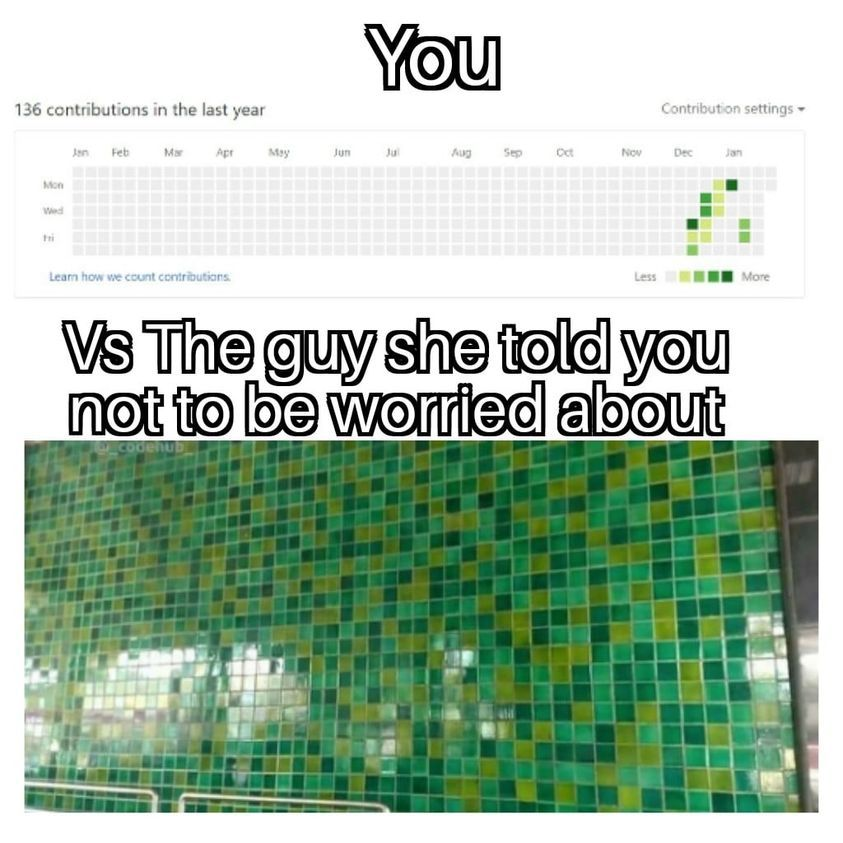



# Алгоритм Диница

### **Необходимые определения**
Введём три необходимых определения (каждое из них является независимым от остальных), которые затем будут использоваться в алгоритме Диница.

**Остаточной сетью** $G^R$ по отношению к сети $G$ и некоторому потоку f в ней называется сеть, в которой каждому ребру $(u,v) \in G$ с пропускной способностью $c_{uv}$ и потоком $f_{uv}$ соответствуют два ребра:

* $(u,v)$ с пропускной способностью $c_{uv}^R = c_{uv} - f_{uv}$
* $(v,u)$ с пропускной способностью $c_{vu}^R = f_{uv}$  

Стоит отметить, что при таком определении в остаточной сети могут появляться кратные рёбра: если в исходной сети было как ребро $(u,v)$, так и $(v,u)$.

Остаточное ребро можно интуитивно понимать как меру того, насколько ещё можно увеличить поток вдоль какого-то ребра. В самом деле, если по ребру $(u,v)$ с пропускной способностью $c_{uv}$ протекает поток $f_{uv}$, то потенциально по нему можно пропустить ещё $c_{uv}-f_{uv}$ единиц потока, а в обратную сторону можно пропустить до $f_{uv}$ единиц потока, что будет означать отмену потока в первоначальном направлении.

**Блокирующим потоком** в данной сети называется такой поток, что любой путь из истока $s$ в сток $t$ содержит **насыщенное** этим потоком ребро. Иными словами, в данной сети не найдётся такого пути из истока в сток, вдоль которого можно беспрепятственно увеличить поток.

Блокирующий поток не обязательно максимален. Теорема Форда-Фалкерсона говорит о том, что поток будет максимальным тогда и только тогда, когда в остаточной сети не найдётся $s$ -> $t$ пути; в блокирующем же потоке ничего не утверждается о существовании пути по рёбрам, появляющимся в остаточной сети.

**Слоистая сеть** для данной сети строится следующим образом. Сначала определяются длины кратчайших путей из истока $s$ до всех остальных вершин; назовём уровнем ${\rm level}[v]$ вершины её расстояние от истока. Тогда в слоистую сеть включают все те рёбра $(u,v)$ исходной сети, которые ведут с одного уровня на какой-либо другой, более поздний, уровень, т.е. ${\rm level}[u] + 1 = {\rm level}[v]$ (почему в этом случае разница расстояний не может превосходить единицы, следует из свойства кратчайших расстояний). Таким образом, удаляются все рёбра, расположенные целиком внутри уровней, а также рёбра, ведущие назад, к предыдущим уровням.

Очевидно, слоистая сеть ациклична. Кроме того, любой s-t путь в слоистой сети является кратчайшим путём в исходной сети.

Построить слоистую сеть по данной сети очень легко: для этого надо запустить обход в ширину по рёбрам этой сети, посчитав тем самым для каждой вершины величину ${\rm level}[]$, и затем внести в слоистую сеть все подходящие рёбра.

**Примечание**. Термин "слоистая сеть" в русскоязычной литературе не употребляется; обычно эта конструкция называется просто "вспомогательным графом". Впрочем, на английском языке обычно используется термин "layered network".

### Схема алгоритма
Алгоритм представляет собой несколько фаз. На каждой фазе сначала строится остаточная сеть, затем по отношению к ней строится слоистая сеть (обходом в ширину), а в ней ищется произвольный блокирующий поток. Найденный блокирующий поток прибавляется к текущему потоку, и на этом очередная итерация заканчивается.

Этот алгоритм схож с алгоритмом Эдмондса-Карпа, но основное отличие можно понимать так: на каждой итерации поток увеличивается не вдоль одного кратчайшего $s$ -> $t$ пути, а вдоль целого набора таких путей (ведь именно такими путями и являются пути в блокирующем потоке слоистой сети).

### Поиск блокирующего потока
Чтобы завершить построение алгоритма Диница, надо описать алгоритм нахождения блокирующего потока в слоистой сети — ключевое место алгоритма.

Мы рассмотрим три возможных варианта реализации поиска блокирующего потока:

1. Искать $s$ -> $t$ пути по одному, пока такие пути находятся.

Путь можно найти за $O(m)$ обходом в глубину, а всего таких путей будет $O(m)$ (поскольку каждый путь насыщает как минимум одно ребро). Итоговая асимптотика поиска одного блокирующего потока составит $O(m^2)$.

2. Аналогично предыдущей идее, однако удалять в процессе обхода в глубину из графа все "лишние" рёбра, т.е. рёбра, вдоль которых не получится дойти до стока.

Это очень легко реализовать: достаточно удалять ребро после того, как мы просмотрели его в обходе в глубину (кроме того случая, когда мы прошли вдоль ребра и нашли путь до стока). С точки зрения реализации, надо просто поддерживать в списке смежности каждой вершины указатель на первое неудалённое ребро, и увеличивать этот указать в цикле внутри обхода в глубину.

Оценим асимптотику этого решения. Каждый обход в глубину завершается либо насыщением как минимум одного ребра (если этот обход достиг стока), либо продвижением вперёд как минимум одного указателя (в противном случае). Можно понять, что один запуск обхода в глубину из основной программы работает за $O (k + n)$, где $k$ — число продвижений указателей. Учитывая, что всего запусков обхода в глубину в рамках поиска одного блокирующего потока будет $O (p)$, где $p$ — число рёбер, насыщенных этим блокирующим потоком, то весь алгоритм поиска блокирующего потока отработает за $O (p k + p n)$, что, учитывая, что все указатели в сумме прошли расстояние $O (m)$, даёт асимптотику $O (m + pn)$. В худшем случае, когда блокирующий поток насыщает все рёбра, асимптотика получается $O (n m)$; эта асимптотика и будет использоваться далее.

Этот способ решения является по-прежнему простым для реализации, но достаточно эффективным, и потому наиболее часто применяется на практике.

### Асимптотика

Таким образом, весь алгоритм Диница выполняется за $O (n^2 m)$, если блокирующий поток искать описанным выше способом за $O (n m)$.

Временная сложность реализации Эдмонда-Карпа равна $O(VE^2)$. Алгоритм Диница - $O(EV^2)$.

Как и алгоритм Эдмонда-Карпа, алгоритм Диница использует следующие концепции:

* Поток является максимальным, если в остаточном графе нет пути от s к t.
* BFS используется в цикле. Однако есть разница в том, как мы используем BFS в обоих алгоритмах.
В алгоритме Эдмонда-Карпа мы используем BFS, чтобы найти дополнительный путь и отправить поток по этому пути. В алгоритме Диника мы используем BFS, чтобы проверить, возможен ли дополнительный поток, и построить граф уровней. В графе уровней мы назначаем уровни всем узлам, уровень узла — это наименьшее расстояние (по количеству рёбер) от узла от источника. После построения графа уровней мы отправляем несколько потоков с помощью этого графа уровней. Вот почему он работает лучше, чем Эдмонд-Карп.

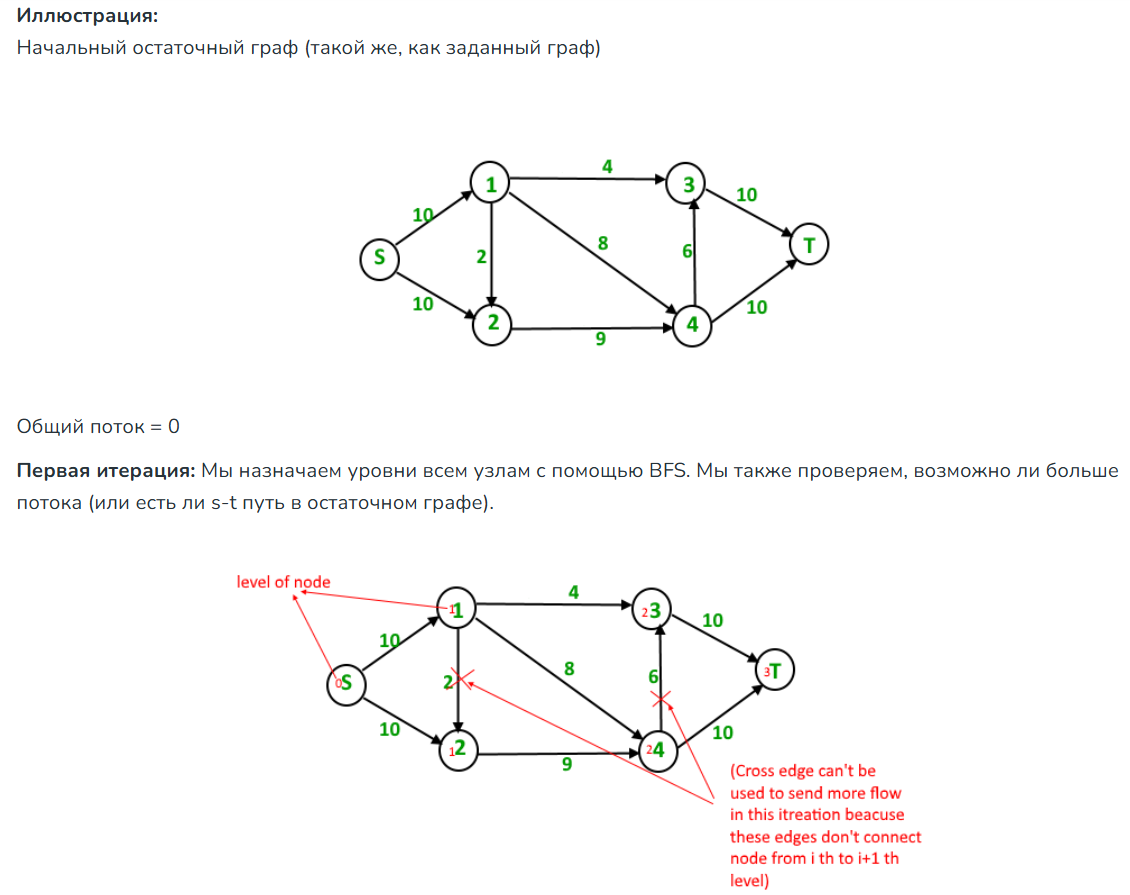

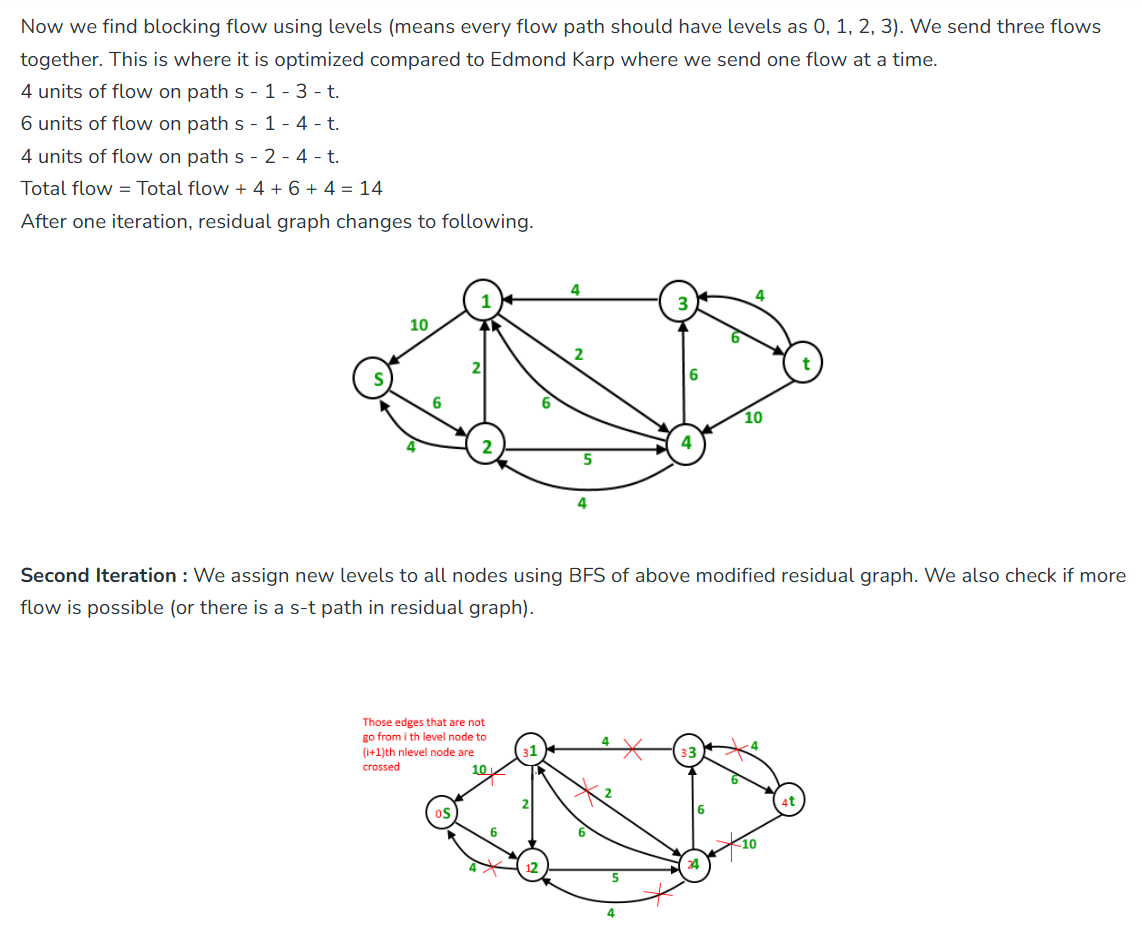

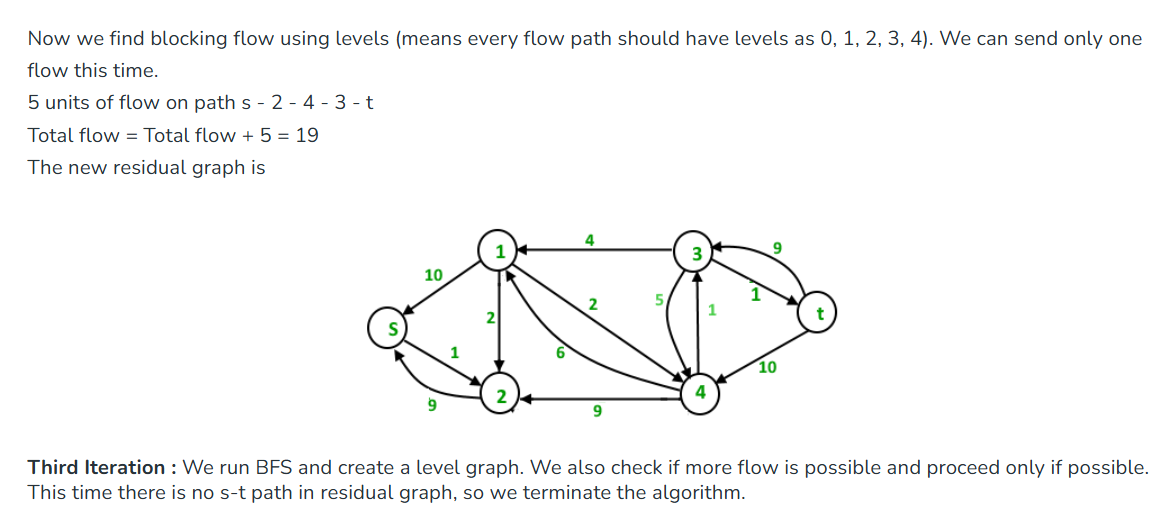

In [2]:
# Python implementation of Dinic's Algorithm
class Edge:
    def __init__(self, v, flow, C, rev):
        self.v = v
        self.flow = flow
        self.C = C
        self.rev = rev

# Residual Graph


class Graph:
    def __init__(self, V):
        self.adj = [[] for i in range(V)]
        self.V = V
        self.level = [0 for i in range(V)]

    # add edge to the graph
    def addEdge(self, u, v, C):

        # Forward edge : 0 flow and C capacity
        a = Edge(v, 0, C, len(self.adj[v]))

        # Back edge : 0 flow and 0 capacity
        b = Edge(u, 0, 0, len(self.adj[u]))
        self.adj[u].append(a)
        self.adj[v].append(b)

    # Finds if more flow can be sent from s to t
    # Also assigns levels to nodes
    def BFS(self, s, t):
        for i in range(self.V):
            self.level[i] = -1

        # Level of source vertex
        self.level[s] = 0

        # Create a queue, enqueue source vertex
        # and mark source vertex as visited here
        # level[] array works as visited array also
        q = []
        q.append(s)
        while q:
            u = q.pop(0)
            for i in range(len(self.adj[u])):
                e = self.adj[u][i]
                if self.level[e.v] < 0 and e.flow < e.C:

                    # Level of current vertex is
                    # level of parent + 1
                    self.level[e.v] = self.level[u]+1
                    q.append(e.v)

        # If we can not reach to the sink we
        # return False else True
        return False if self.level[t] < 0 else True

# A DFS based function to send flow after BFS has
# figured out that there is a possible flow and
# constructed levels. This functions called multiple
# times for a single call of BFS.
# flow : Current flow send by parent function call
# start[] : To keep track of next edge to be explored
#           start[i] stores count of edges explored
#           from i
# u : Current vertex
# t : Sink
    def sendFlow(self, u, flow, t, start):
        # Sink reached
        if u == t:
            return flow

        # Traverse all adjacent edges one -by -one
        while start[u] < len(self.adj[u]):

            # Pick next edge from adjacency list of u
            e = self.adj[u][start[u]]
            if self.level[e.v] == self.level[u]+1 and e.flow < e.C:

                # find minimum flow from u to t
                curr_flow = min(flow, e.C-e.flow)
                temp_flow = self.sendFlow(e.v, curr_flow, t, start)

                # flow is greater than zero
                if temp_flow and temp_flow > 0:

                    # add flow to current edge
                    e.flow += temp_flow

                    # subtract flow from reverse edge
                    # of current edge
                    self.adj[e.v][e.rev].flow -= temp_flow
                    return temp_flow
            start[u] += 1

    # Returns maximum flow in graph
    def DinicMaxflow(self, s, t):

        # Corner case
        if s == t:
            return -1

        # Initialize result
        total = 0

        # Augument the flow while there is path
        # from source to sink
        while self.BFS(s, t) == True:

            # store how many edges are visited
            # from V { 0 to V }
            start = [0 for i in range(self.V+1)]
            while True:
                flow = self.sendFlow(s, float('inf'), t, start)
                if not flow:
                    break

                # Add path flow to overall flow
                total += flow

        # return maximum flow
        return total


g = Graph(6)
g.addEdge(0, 1, 10)
g.addEdge(0, 2, 10)
g.addEdge(1, 2, 2)
g.addEdge(1, 3, 4)
#g.addEdge(2, 1, 4)
g.addEdge(1, 4, 8)
g.addEdge(2, 4, 9)
g.addEdge(3, 5, 10)
g.addEdge(4, 3, 6)
g.addEdge(4, 5, 10)
print("Maximum flow", g.DinicMaxflow(0, 5))

# This code is contributed by rupasriachanta421.

Maximum flow 19


# Алгоритм Хопкрофта–Карпа

Алгоритм Хопкрофта–Карпа — один из самых быстрых алгоритмов для поиска максимального паросочетания в двудольном графе.

**Идея задачи**:
Есть двудольный граф:

* вершины разбиты на две части: $𝐿$ и $𝑅$

* рёбра только между частями

Нужно выбрать максимальное количество рёбер так, чтобы:

никакие два выбранных ребра не имели общих вершин.

Это называется максимальное паросочетание.

До него использовали алгоритмы, которые добавляли по одному увеличивающему пути.
Хопкрофт–Карп ускорил процесс:

Он делает так:

* Сначала ищет все кратчайшие увеличивающие пути (через BFS).

* Затем одновременно увеличивает паросочетание по многим таким путям (через DFS).

То есть алгоритм работает пакетами путей, а не по одному.


**Шаги алгоритма**

1. Каждая итерация:

* BFS
* строим слоистую сеть (уровневый граф)
* находим длину кратчайших увеличивающих путей.

2. DFS

* ищем максимально возможное количество таких путей
* увеличиваем паросочетание.

3. Повторяем, пока пути существуют.



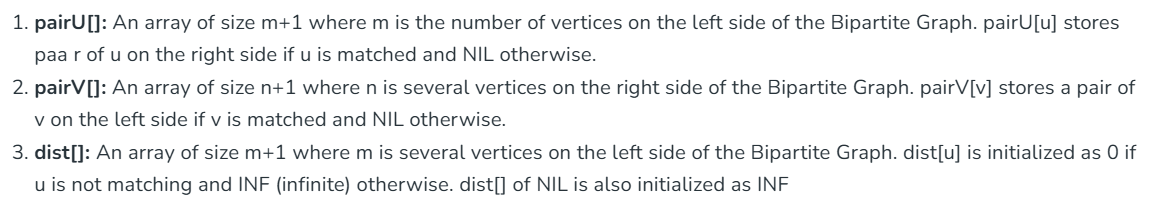

In [3]:
# Python3 implementation of Hopcroft Karp algorithm for
# maximum matching
from queue import Queue

INF = 2147483647
NIL = 0

# A class to represent Bipartite graph for Hopcroft
# 3 Karp implementation
class BipGraph(object):
    # Constructor
    def __init__(self, m, n):
        # m and n are number of vertices on left
        # and right sides of Bipartite Graph
        self.__m = m
        self.__n = n
        # adj[u] stores adjacents of left side
        # vertex 'u'. The value of u ranges from 1 to m.
        # 0 is used for dummy vertex
        self.__adj = [[] for _ in range(m+1)]

    # To add edge from u to v and v to u
    def addEdge(self, u, v):
        self.__adj[u].append(v)  # Add u to v’s list.

    # Returns true if there is an augmenting path, else returns
    # false
    def bfs(self):
        Q = Queue()
        # First layer of vertices (set distance as 0)
        for u in range(1, self.__m+1):
            # If this is a free vertex, add it to queue
            if self.__pairU[u] == NIL:
                # u is not matched3
                self.__dist[u] = 0
                Q.put(u)
            # Else set distance as infinite so that this vertex
            # is considered next time
            else:
                self.__dist[u] = INF
        # Initialize distance to NIL as infinite
        self.__dist[NIL] = INF
        # Q is going to contain vertices of left side only.
        while not Q.empty():
            # Dequeue a vertex
            u = Q.get()
            # If this node is not NIL and can provide a shorter path to NIL
            if self.__dist[u] < self.__dist[NIL]:
                # Get all adjacent vertices of the dequeued vertex u
                for v in self.__adj[u]:
                    #  If pair of v is not considered so far
                    # (v, pairV[V]) is not yet explored edge.
                    if self.__dist[self.__pairV[v]] == INF:
                        # Consider the pair and add it to queue
                        self.__dist[self.__pairV[v]] = self.__dist[u] + 1
                        Q.put(self.__pairV[v])
        # If we could come back to NIL using alternating path of distinct
        # vertices then there is an augmenting path
        return self.__dist[NIL] != INF

    # Returns true if there is an augmenting path beginning with free vertex u
    def dfs(self, u):
        if u != NIL:
            # Get all adjacent vertices of the dequeued vertex u
            for v in self.__adj[u]:
                if self.__dist[self.__pairV[v]] == self.__dist[u] + 1:
                    # If dfs for pair of v also returns true
                    if self.dfs(self.__pairV[v]):
                        self.__pairV[v] = u
                        self.__pairU[u] = v
                        return True
            # If there is no augmenting path beginning with u.
            self.__dist[u] = INF
            return False
        return True

    def hopcroftKarp(self):
        # pairU[u] stores pair of u in matching where u
        # is a vertex on left side of Bipartite Graph.
        # If u doesn't have any pair, then pairU[u] is NIL
        self.__pairU = [0 for _ in range(self.__m+1)]

        # pairV[v] stores pair of v in matching. If v
        # doesn't have any pair, then pairU[v] is NIL
        self.__pairV = [0 for _ in range(self.__n+1)]

        # dist[u] stores distance of left side vertices
        # dist[u] is one more than dist[u'] if u is next
        # to u'in augmenting path
        self.__dist = [0 for _ in range(self.__m+1)]
        # Initialize result
        result = 0

        # Keep updating the result while there is an
        # augmenting path.
        while self.bfs():
            # Find a free vertex
            for u in range(1, self.__m+1):
                # If current vertex is free and there is
                # an augmenting path from current vertex
                if self.__pairU[u] == NIL and self.dfs(u):
                    result += 1
        return result


# Driver Program
if __name__ == "__main__":
    g = BipGraph(4, 4)
    g.addEdge(1, 2)
    g.addEdge(1, 3)
    g.addEdge(2, 1)
    g.addEdge(3, 2)
    g.addEdge(4, 2)
    g.addEdge(4, 4)
    print("Size of maximum matching is %d" % g.hopcroftKarp())

Size of maximum matching is 4


### Сложность

Алгоритм работает за $𝑂(𝐸\sqrt{𝑉})$, $V$ — вершины, $𝐸$ — рёбра.



### Теорема Карзанова
Теорема Карзанова связана с тем, почему алгоритм Хопкрофта–Карпа работает так быстро.

После каждой фазы алгоритма длина кратчайшего увеличивающего пути строго увеличивается. Следствие - таких фаз может быть не больше примерно $\sqrt{𝑉}$.

А каждая фаза - $O(E)$ Отсюда итоговая сложность: $O(E\sqrt{V})$
Когда алгоритм за одну фазу использует все кратчайшие увеличивающие пути, он "уничтожает" возможность существования других путей такой же длины. Поэтому следующие пути будут длиннее, а длинных путей не может быть слишком много.


# Алгоритм A*

Алгоритм A* является высокоэффективным и хорошо известным методом поиска, используемым для поиска наиболее эффективного пути между двумя точками графа. Он применяется в таких ситуациях, как поиск путей в видеоиграх, сетевая маршрутизация и различные приложения искусственного интеллекта (ИИ). Он был разработан в 1968 году Питером Хартом, Нильсом Нильссоном и Бертрамом Рафаэлем как усовершенствование алгоритма Дейкстры.

* В то время как алгоритм Дейкстры равномерно исследует все возможные направления вокруг начального узла
* A* объединяет фактические затраты с предполагаемыми будущими затратами (эвристики)

**Ключевые компоненты алгоритма A***
A* использует два важных параметра для определения стоимости пути:
* $g(n)$: Фактическая стоимость достижения узла $n$ от стартового узла. Это накопленная стоимость пути от стартового узла к узлу $n$.

* $h(n)$: Эвристические находки стоимости достижения цели из узла $n$. Это взвешенное предположение о том, сколько ещё времени потребуется, чтобы достичь цели.

Функция $f(n)=g(n)+h(n) $— общая оценочная стоимость самого дешёвого решения через узел $n$. Эта функция объединяет стоимость пути на данный момент и эвристическую стоимость для более эффективной оценки общей стоимости, направляющей поиск.

## Как работает алгоритм A*?
A* — это алгоритм информированного поиска, то есть он использует
$f(n)$ функцию, которая определяет приоритеты,т.е. какие узлы исследовать дальше. Процесс можно разделить на следующие этапы:

* **Инициализация**: Начальный узел добавляется в открытое множество — набор узлов, которые ещё предстоит исследовать. Значение функции $f(n)$ для начального узла вычисляется с помощью эвристики.

* **Цикл**: A* выбирает узел с наименьшим значением функции $f(n)$ из открытого множества. Этот узел расширяется, и его соседи исследуются.

* **Проверка цели**: Если обрабатываемый узел является целевым, поиск завершается, и алгоритм возвращает путь к цели.

* **Расширение узла**: Каждый сосед текущего узла оценивается на основе значений $g(n)$, $h(n)$ и $f(n)$. Если найден лучший путь к соседу, то есть более низкий $f(n)$ затем сосед добавляется в открытый набор или его значения обновляются.

* **Повторение**: этот процесс продолжается до тех пор, пока не найдена цель или открытое множество не опустеет, а значит, решения нет.

## Эвристики
Эффективность алгоритма A* во многом зависит от эвристической функции. Выбор эвристики может повлиять на производительность и эффективность алгоритма. Хорошая эвристика — это та, которая помогает алгоритму найти самый короткий путь, исследуя минимальное количество узлов.

**Свойства хорошей эвристики**:
Хорошая эвристическая функция может улучшить результаты A*. Некоторые важные характеристики включают:

* **Допустимость**: это означает, что эвристика никогда не угадывает стоимость, превышающую фактическую стоимость для достижения цели. Это помогает A* всегда находить самый короткий путь. Например, использование прямолинейного расстояния на карте является допустимой эвристикой.

* **Согласованность (Монотонность)**: это значит, что эвристика даёт оценки, которые не слишком сильно скачут. Для любого узла и его следующего шага стоимость достижения цели не должна превышать переход к следующему шагу, а затем к цели. Это помогает A* избежать повторной проверки одних и тех же узлов и ускоряет процесс.

**Распространённые эвристики**:

* **Манхэттенское расстояние**: используется для сеточных сред, где перемещение ограничено горизонтальными и вертикальными направлениями. Он вычисляет сумму абсолютных разностей в $x$ и $y$ координаты между двумя точками.

* **Евклидово расстояние**: прямое расстояние между двумя точками, часто используемое при разрешенном движении в любом направлении.

* **Расстояние Чебышева**: Используется при разрешенном диагональном движении.

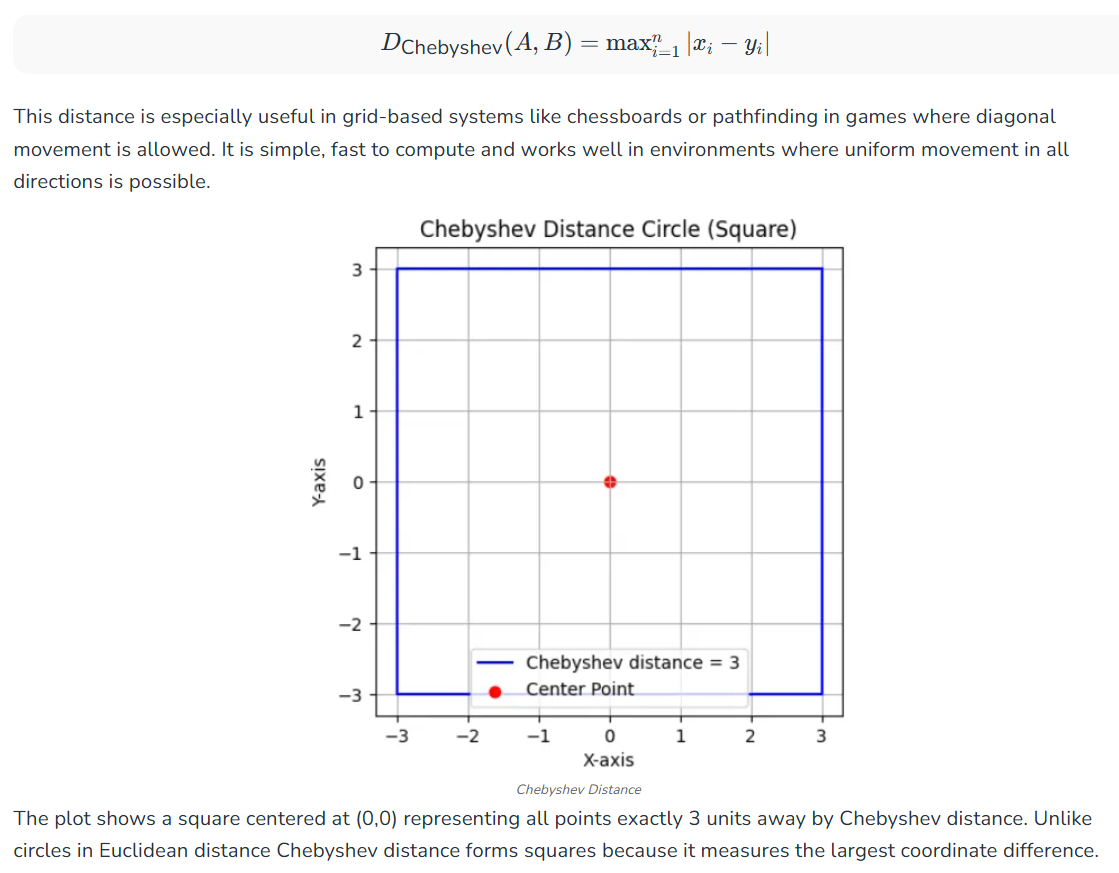

https://www.geeksforgeeks.org/machine-learning/chebyshev-distance/

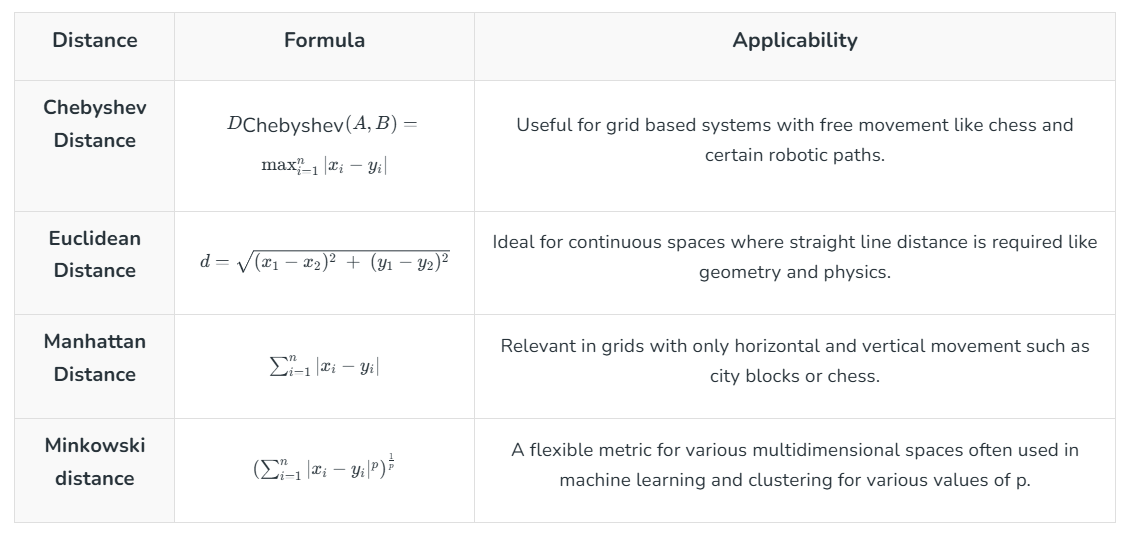

## Реализация примера поиска пути с использованием алгоритма A*
Давайте реализуем алгоритм A* на Python и визуализируем процесс.

**Шаг 1**: Импорт необходимых библиотек

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

**Шаг 2**: Определение эвристической функции
Мы будем использовать манхэттенское расстояние как эвристическую функцию для оценки стоимости от текущего узла до цели. Эта эвристика подходит для задач поиска пути на основе сетки, где движение ограничено горизонтальными и вертикальными направлениями.

In [1]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

**Шаг 3**: Реализация алгоритма A*  
Здесь мы определяем алгоритм A*, который использует очередь приоритетов для изучения узлов на основе общей оценочной стоимости $f(n)=g(n)+h(n)$, где:
$g(n)$— стоимость от стартового узла к текущему.
$h(n)$— эвристическая оценочная стоимость от текущего узла до цели.

Алгоритм поддерживает три ключевые структуры:

* open_set: очередь приоритетов, содержащая узлы для исследования, упорядоченные по $f(n)$.
* came_from: словарь, который помогает восстановить путь после достижения цели.
* g_score и f_score: словари, которые хранят фактическую стоимость каждого узла ($g(n)$) и предполагаемую стоимость достижения цели ($f(n)$) соответственно.
В каждой итерации мы разворачиваем узел с наименьшим значением $f(n)$. Для каждого соседа текущего узла алгоритм вычисляет
$g$ и $f$ и обновляет их, если нашелся лучший путь.

In [3]:
def a_star(graph, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0
    f_score = {node: float('inf') for node in graph}
    f_score[start] = heuristic(start, goal)

    while open_set:
        _, current = heapq.heappop(open_set)
        if current == goal:
            return reconstruct_path(came_from, current)

        for neighbor, cost in graph[current].items():
            tentative_g_score = g_score[current] + cost
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return None

**Шаг 4**: Определение функции реконструкции пути
После достижения целевого узла нужно восстановить путь от начального узла к цели. Это делается путём обратного перехода от цели к началу с помощью словаря came_from, который хранит предшественника каждого узла вдоль пути. После сбора узлов в обратном порядке мы поворачиваем путь, чтобы получить финальную последовательность от начала до цели.

In [4]:
def reconstruct_path(came_from, current):
    total_path = [current]
    while current in came_from:
        current = came_from[current]
        total_path.append(current)
    total_path.reverse()
    return total_path

def path_to_edges(path):
    return [(path[i], path[i + 1]) for i in range(len(path) - 1)]

**Шаг 5**: Построение графика и визуализация пути
Здесь мы определяем простой граф на основе сетки, где каждый узел соединён со своими соседями. Граф представлен как словарь узлов, где ключи — координаты, а значения — словари соседей с соответствующими весами рёбер (cost).

Затем мы используем библиотеку NetworkX, чтобы визуализировать график и выделить путь, найденный алгоритмом A*. Путь визуализируется с помощью красного цвета рёбер графа.

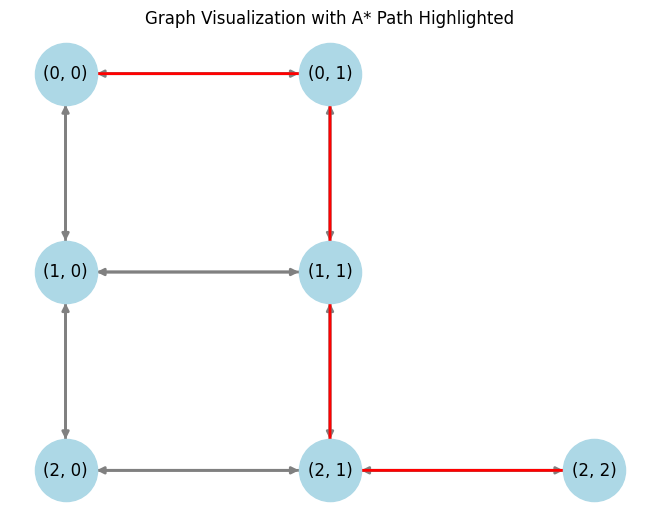

In [5]:
graph = {
    (0, 0): {(1, 0): 1, (0, 1): 1},
    (1, 0): {(0, 0): 1, (1, 1): 1, (2, 0): 1},
    (0, 1): {(0, 0): 1, (1, 1): 1},
    (1, 1): {(1, 0): 1, (0, 1): 1, (2, 1): 1},
    (2, 0): {(1, 0): 1, (2, 1): 1},
    (2, 1): {(2, 0): 1, (1, 1): 1, (2, 2): 1},
    (2, 2): {(2, 1): 1}
}

start = (0, 0)
goal = (2, 2)

G = nx.DiGraph()
for node, edges in graph.items():
    for dest, weight in edges.items():
        G.add_edge(node, dest, weight=weight)

path = a_star(graph, start, goal)

pos = {node: (node[1], -node[0]) for node in graph}
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, edge_color='gray', width=2)
nx.draw_networkx_edges(G, pos, edgelist=path_to_edges(path), edge_color='red', width=2)
plt.title('Graph Visualization with A* Path Highlighted')
plt.show()

* Рёбра — это линии, соединяющие узлы. Серые рёбра обозначают все возможные пути, а красные рёбра выделяют выбранный алгоритмом A* путь.
Выделенный красным цветом путь показывает оптимальный маршрут, определённый алгоритмом A*. Этот путь идёт от (0, 0) до (0, 1), затем переходит к (1, 1), продолжается до (2, 1) и, наконец, достигает цели в (2, 2).
Эта визуализация помогает понять решения, принимаемые алгоритмом A* при навигации по графу и поиске наиболее эффективного пути.

### Применение алгоритма A*
Способность алгоритма A* находить наиболее эффективный путь с помощью заданной эвристики делает его подходящим для различных практических применений:

* Навигация в играх и робототехнике: A* используется в игровой индустрии для управления персонажами в динамических средах, а также в робототехнике для перемещения между точками.
* Сетевая маршрутизация: в телекоммуникациях она помогает найти самый короткий путь маршрутизации, по которому должны идти пакеты данных, чтобы добраться до пункта назначения.
* ИИ и машинное обучение: Это может использоваться в алгоритмах планирования и принятия решений, где необходимо оценивать несколько этапов принятия решений и движений.
* Системы карты и навигации: GPS-навигационные системы используют A* для поиска оптимальных маршрутов для вождения или пеших прогулок в реальном времени.
* Логистика и цепочка поставок: A* помогает оптимизировать маршруты для транспортных средств и складских роботов, чтобы минимизировать время и затраты на дорогу.